In [1]:
from google.colab import auth
auth.authenticate_user()

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%cd /content
!git clone https://github.com/UrbinaDan/PaperTheater_ai_Pipeline.git
%cd PaperTheater_ai_Pipeline

/content
fatal: destination path 'PaperTheater_ai_Pipeline' already exists and is not an empty directory.
/content/PaperTheater_ai_Pipeline


In [3]:
!pip install -q -r requirements-colab.txt

In [4]:
import torch
print("CUDA:", torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

CUDA: True
Tesla T4


In [5]:
%cd /content
!git clone https://github.com/facebookresearch/sam2.git
%cd /content/sam2
!pip install -e .

/content
fatal: destination path 'sam2' already exists and is not an empty directory.
/content/sam2
Obtaining file:///content/sam2
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for SAM-2 (pyproject.toml) ... done
  Created wheel for SAM-2: filename=sam_2-1.0-0.editable-cp312-cp312-linux_x86_64.whl size=13851 sha256=f2631438956e6f1b20ac42d40f8863a5569113135baea239964d9c17f1361cfc
  Stored in directory: /tmp/pip-ephem-wheel-cache-5clioc9_/wheels/9e/fa/17/14aaeb20d3ca07c58ee93742054d4479f89c243063ce0b61b9
Successfully built SAM-2
  Attempting uninstall: SAM-2
    Found existing installation: SAM-2 1.0
    Uninstalling SAM-2-1.0:
      Successfully uninstalled SAM-2-1.0


In [6]:
!mkdir -p checkpoints
!wget -q -P checkpoints https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_small.pt
!wget -q -P checkpoints https://raw.githubusercontent.com/facebookresearch/sam2/main/sam2_configs/sam2_hiera_s.yaml

In [7]:
%cd /content
!git clone https://github.com/DepthAnything/Depth-Anything-V2.git
%cd /content/Depth-Anything-V2
!pip install -q -r requirements.txt || true

/content
fatal: destination path 'Depth-Anything-V2' already exists and is not an empty directory.
/content/Depth-Anything-V2


In [8]:
%cd /content/Depth-Anything-V2
!mkdir -p checkpoints
!wget -q -P checkpoints https://huggingface.co/depth-anything/Depth-Anything-V2-Small/resolve/main/depth_anything_v2_vits.pth

/content/Depth-Anything-V2


In [9]:
import os
from getpass import getpass

os.environ["OPENAI_API_KEY"] = getpass("Enter your OpenAI key: ")

Enter your OpenAI key: ··········


In [10]:
%cd /content/PaperTheater_ai_Pipeline
import sys
sys.path.append("/content/PaperTheater_ai_Pipeline")

/content/PaperTheater_ai_Pipeline


In [11]:
!pip uninstall -y transformers tokenizers
!pip install -q "transformers==4.49.0" "tokenizers==0.21.4"

Found existing installation: transformers 4.49.0
Uninstalling transformers-4.49.0:
  Successfully uninstalled transformers-4.49.0
Found existing installation: tokenizers 0.21.4
Uninstalling tokenizers-0.21.4:
  Successfully uninstalled tokenizers-0.21.4


TESTS


In [12]:
from src.depth_anything_runner import DepthRunner

depth_runner = DepthRunner()
print("Depth model loaded")

Depth model loaded


In [13]:
from src.sam2_segmenter import SAM2Segmenter

segmenter = SAM2Segmenter()
print("SAM2 loaded")

SAM2 loaded


In [14]:
from src.depth_anything_runner import DepthRunner

depth_runner = DepthRunner()
print("Depth model loaded")

Depth model loaded


**Occlusion and completion**
Step 2

In [15]:
%cd /content/PaperTheater_ai_Pipeline

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from src.config import Paths, PipelineConfig
from src.io_utils import ensure_dirs, load_image, save_mask, save_json
from src.florence_parser import FlorenceParser
from src.sam2_segmenter import SAM2Segmenter
from src.depth_anything_runner import DepthRunner
from src.scene_builder import parse_florence_boxes, assign_layers
from src.occlusion_heuristic import heuristic_complete
from src.occlusion_amodal import amodal_experimental
from src.mask_cleanup import cleanup_mask


/content/PaperTheater_ai_Pipeline


In [16]:
paths = Paths()
cfg = PipelineConfig()
ensure_dirs(paths)

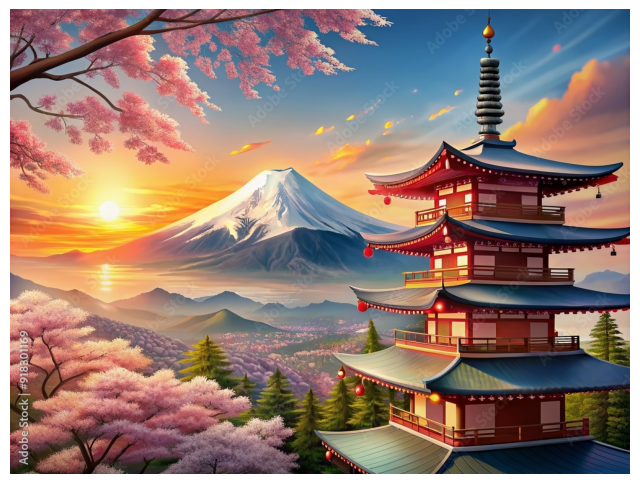

In [17]:
image_path = "/content/PaperTheater_ai_Pipeline/data/input/scene_1.jpg"
image = load_image(image_path, max_side=cfg.image_max_side)

plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.axis("off")
plt.show()

In [18]:
florence = FlorenceParser(cfg.florence_model)

caption = florence.get_dense_caption(image)
caption

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

processing_florence2.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-base:
- processing_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


tokenizer_config.json:   0%|          | 0.00/34.0 [00:00<?, ?B/s]

...

A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-base:
- configuration_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_florence2.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-base:
- modeling_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/463M [00:00<?, ?B/s]

RuntimeError: Input type (float) and bias type (c10::Half) should be the same

In [ ]:
det = florence.get_open_vocab_detection(
    image,
    "tree, temple, pagoda, house, building, bridge, mountain, sky, bush, foreground plant"
)
det

In [ ]:
boxes = parse_florence_boxes(det)
boxes[:5]

In [ ]:
segmenter = SAM2Segmenter(cfg.sam2_config, cfg.sam2_checkpoint)
segmented = segmenter.segment_boxes(image, boxes)

len(segmented), segmented[0].keys()

In [ ]:
sample = segmented[0]
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.imshow(sample["mask"], alpha=0.4)
plt.title(sample["label"])
plt.axis("off")
plt.show()

In [ ]:
depth_runner = DepthRunner(cfg.depth_encoder)
depth = depth_runner.infer(image)

plt.figure(figsize=(8, 8))
plt.imshow(depth, cmap="plasma")
plt.axis("off")
plt.title("Depth map")
plt.show()

In [ ]:
layer_assignments = assign_layers(segmented, depth, cfg.target_num_layers)
layer_assignments

In [ ]:
heuristic_results = []

for i, obj in enumerate(segmented):
    completed = heuristic_complete(obj["mask"], obj["label"])
    cleaned = cleanup_mask(completed, cfg.min_component_area, cfg.smooth_kernel)

    out_path = paths.completed_dir / f"heuristic_{i:03d}.png"
    save_mask(out_path, cleaned)

    heuristic_results.append({
        "index": i,
        "label": obj["label"],
        "bbox": obj["bbox"],
        "layer": layer_assignments[i],
        "mask_path": str(out_path)
    })

heuristic_results[:3]

In [ ]:
from src.occlusion_openai import openai_edit
from PIL import Image

In [ ]:
openai_results = []

for i, obj in enumerate(segmented):
    guess = heuristic_complete(obj["mask"], obj["label"])
    cleaned_mask = cleanup_mask(guess, cfg.min_component_area, cfg.smooth_kernel)

    # use this only on structured labels
    label = obj["label"].lower()
    structured = any(x in label for x in ["temple", "pagoda", "building", "house", "bridge", "roof"])

    if structured:
        edited = openai_edit(image, cleaned_mask, obj["label"], cfg.openai_model)
        out_img = paths.completed_dir / f"openai_edit_{i:03d}.png"
        Image.fromarray(edited).save(out_img)

    out_mask = paths.completed_dir / f"openai_mask_{i:03d}.png"
    save_mask(out_mask, cleaned_mask)

    openai_results.append({
        "index": i,
        "label": obj["label"],
        "bbox": obj["bbox"],
        "layer": layer_assignments[i],
        "mask_path": str(out_mask)
    })

In [ ]:
amodal_results = []

for i, obj in enumerate(segmented):
    completed = amodal_experimental(obj["mask"], obj["label"])
    cleaned = cleanup_mask(completed, cfg.min_component_area, cfg.smooth_kernel)

    out_path = paths.completed_dir / f"amodal_{i:03d}.png"
    save_mask(out_path, cleaned)

    amodal_results.append({
        "index": i,
        "label": obj["label"],
        "bbox": obj["bbox"],
        "layer": layer_assignments[i],
        "mask_path": str(out_path)
    })



## --- SECTION 3
VECTOR EXPORT




In [ ]:
%cd /content/paper-theater-ai

from src.config import Paths, PipelineConfig
from src.io_utils import load_mask
from src.vectorize import mask_to_polygons
from src.fabrication import merge_polygons, thicken_fragile_parts, remove_tiny_parts
from src.export_svg import save_svg
import numpy as np

In [ ]:
def export_branch(branch_results, branch_name, image_shape):
    paths = Paths()
    cfg = PipelineConfig()

    h, w = image_shape[:2]

    for layer_idx in range(cfg.target_num_layers):
        masks = []
        for item in branch_results:
            if item["layer"] == layer_idx:
                masks.append(load_mask(item["mask_path"]))

        if not masks:
            continue

        merged = np.zeros_like(masks[0], dtype=np.uint8)
        for m in masks:
            merged = ((merged > 0) | (m > 0)).astype(np.uint8)

        polys = mask_to_polygons(merged, cfg.simplify_tolerance)
        geom = merge_polygons(polys)
        geom = remove_tiny_parts(geom, 100)
        geom = thicken_fragile_parts(geom, 2)

        out_path = paths.layers_svg_dir / f"{branch_name}_layer_{layer_idx}.svg"
        save_svg(geom, out_path, w, h)
        print("saved", out_path)

In [ ]:
from PIL import Image
from pathlib import Path
import json

image_path = Paths().input_dir / "scene.png"
img = Image.open(image_path).convert("RGB")
img_np = np.array(img)

# reuse branch results from earlier notebook or load from saved json if you stored them
export_branch(heuristic_results, "heuristic", img_np.shape)
export_branch(amodal_results, "amodal", img_np.shape)
export_branch(openai_results, "openai", img_np.shape)

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

paths = Paths()

for p in sorted(paths.layers_svg_dir.glob("*.svg")):
    print(p.name)

##

---SECTION 4
Compare Results

